# 🧠 SK Hynix HBM 경쟁사 기술 동향 분석 시스템
**Competitive R&D Intelligence for Next-Generation HBM**

| 항목 | 내용 |
|------|------|
| 분석 대상 | Samsung · Micron |
| 분석 기술 | HBM4 · PIM · CXL |
| 아키텍처 | Supervisor Pattern (LangGraph) |
| 최종 산출물 | TRL 기반 경쟁사 기술 동향 분석 보고서 (PDF) |

---

## 📋 실행 순서
1. **환경 설정** — API 키 로드
2. **RAG 초기화** — 벡터스토어 빌드
3. **그래프 빌드** — LangGraph StateGraph 확인
4. **워크플로우 실행** — 분석 주제 입력 → 보고서 생성
5. **보고서 저장** — PDF/Markdown 출력

## 0. 환경 설정

In [1]:
# 패키지 설치 (최초 1회)
# !pip install -r requirements.txt

In [2]:
import sys
import os
import uuid
from pathlib import Path
from dotenv import load_dotenv

# 프로젝트 루트를 Python 경로에 추가
PROJECT_ROOT = Path(".").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

load_dotenv(override=True)

# API 키 확인
openai_key  = os.getenv("OPENAI_API_KEY", "")
tavily_key  = os.getenv("TAVILY_API_KEY", "")
langsmith_key = os.getenv("LANGCHAIN_API_KEY", "")

print(f"✅ OpenAI  API : {'설정됨' if openai_key  else '❌ 미설정 — .env 확인 필요'}")
print(f"   Tavily  API : {'설정됨' if tavily_key  else '⚠️  미설정 — Web 검색 LLM 폴백 모드로 실행'}")
print(f"   LangSmith   : {'설정됨' if langsmith_key else '⚠️  미설정 (선택사항)'}")

✅ OpenAI  API : 설정됨
   Tavily  API : 설정됨
   LangSmith   : 설정됨


In [3]:
# LangSmith 트레이싱 설정 (선택사항 — API 키 있을 때만 활성화)
if langsmith_key:
    os.environ["LANGCHAIN_TRACING_V2"] = "true"
    os.environ["LANGCHAIN_PROJECT"]    = "HBM-Competitive-Intel"
    print("📡 LangSmith 트레이싱 활성화")
else:
    os.environ["LANGCHAIN_TRACING_V2"] = "false"
    print("📡 LangSmith 트레이싱 비활성화 (로컬 실행)")

📡 LangSmith 트레이싱 활성화


## 1. AgentState 확인
설계서 3-1 기반 — 워크플로우 전체 상태를 관리하는 TypedDict

In [4]:
from graph.state import AgentState
import inspect

print("📋 AgentState 필드 구성:")
print(inspect.getsource(AgentState))

/Users/skala059/workspace/ai-service/hbm-competitive-intel/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


📋 AgentState 필드 구성:
class AgentState(TypedDict):
    # ── 공통 ───────────────────────────────────────────────────
    messages: Annotated[Sequence[BaseMessage], operator.add]
    query: str

    # ── 수집 결과 ───────────────────────────────────────────────
    rag_results: Optional[List[RAGResult]]
    web_results: Optional[List[WebResult]]

    # ── TRL 평가 결과 (교수 피드백 — 전용 노드 산출물) ──────────
    trl_assessment: Optional[Dict]

    # ── 보고서 ─────────────────────────────────────────────────
    report: Optional[str]

    # ── Supervisor 제어 ────────────────────────────────────────
    next: str
    retry_count: int



## 2. RAG 파이프라인 초기화
BAAI/bge-m3 임베딩 + FAISS + BM25 Hybrid Retriever (설계서 2-2)

In [5]:
from rag.indexer import build_index          # 팀원 개선: PDF+JSON, 유형별 청킹, 메타데이터 강화
from rag.retriever import HBMRetriever, retrieve_with_scores
from agents.rag_agent import init_rag_retriever

VS_PATH = Path('rag/vectorstore')

# 벡터스토어 빌드 or 로드
if (VS_PATH / 'index.faiss').exists():
    print('📂 기존 벡터스토어 로드...')
    from langchain_huggingface import HuggingFaceEmbeddings
    from langchain_community.vectorstores import FAISS
    embeddings = HuggingFaceEmbeddings(
        model_name='intfloat/multilingual-e5-large',
        encode_kwargs={'normalize_embeddings': True},
    )
    vectorstore = FAISS.load_local(
        str(VS_PATH), embeddings, allow_dangerous_deserialization=True
    )
    print(f'  ✅ 로드 완료')
else:
    print('🔨 벡터스토어 신규 빌드 (indexer.py — PDF+JSON 유형별 청킹)...')
    vectorstore = build_index()  # ← 팀원 indexer 사용
    if vectorstore is None:
        raise RuntimeError('data/ 폴더에 문서가 없습니다. PDF/JSON 파일을 추가하세요.')

# HBMRetriever 초기화 (reranker + query expansion)
retriever = HBMRetriever(use_reranker=True)
init_rag_retriever(retriever)

# all_chunks는 BM25 내부에서 관리되므로 별도 불필요
all_docs = list(vectorstore.docstore._dict.values())
print(f'\n✅ RAG 초기화 완료 | 문서 수: {len(all_docs)}개')
print(f'   임베딩: intfloat/multilingual-e5-large')
print(f'   검색전략: BM25 + Dense RRF + CrossEncoder Reranker')
print(f'   문서유형: PDF(chunk=900) + JSON(chunk=320) 유형별 청킹 적용')


📂 기존 벡터스토어 로드...


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 11242.39it/s]
XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  ✅ 로드 완료

✅ RAG 초기화 완료 | 문서 수: 443개
   임베딩: intfloat/multilingual-e5-large
   검색전략: BM25 + Dense RRF + CrossEncoder Reranker
   문서유형: PDF(chunk=900) + JSON(chunk=320) 유형별 청킹 적용


### 2-1. RAG 검색 테스트

In [6]:
test_query = "HBM4 Hybrid Bonding TSV 수율"
test_results = retrieve_with_scores(retriever, test_query, k=3)

print(f"🔍 테스트 쿼리: '{test_query}'")
print(f"   검색 결과 {len(test_results)}건:")
for i, r in enumerate(test_results, 1):
    print(f"\n  [{i}] 출처: {r['source']} | 점수: {r['score']}")
    print(f"      요약: {r['summary'][:100]}...")

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 10281.32it/s]
XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 105/105 [00:00<00:00, 8950.53it/s]
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


🔍 테스트 쿼리: 'HBM4 Hybrid Bonding TSV 수율'
   검색 결과 3건:

  [1] 출처: hbm4_hybrid_bonding.txt | 점수: 8.75
      요약: # HBM4 및 Hybrid Bonding 기술 심층 분석 ## 1. HBM4 기술 개요 HBM4(High Bandwidth Memory 4)는 DRAM 다이를 수직으로 적층하여 ...

  [2] 출처: hbm4_hybrid_bonding.txt | 점수: 8.47
      요약: . HBM4 이상에서 기존 MR-MUF(Mass Reflow-Molded Underfill)를 대체할 핵심 공정으로 부상하였다. Hybrid Bonding의 장점: - 범프 피치:...

  [3] 출처: hbm4_hybrid_bonding.txt | 점수: 8.14
      요약: . 수율·공정 파라미터 비공개. 불확실성 높음. ## 8. 전략적 시사점 HBM4/Hybrid Bonding에서의 경쟁 위협 수준은 보통으로 평가된다. Samsung은 파운드리 내...


## 3. LangGraph 그래프 빌드
설계서 3-3 Graph 구현 구조

In [7]:
from graph.workflow import build_graph, get_initial_state

graph = build_graph(use_checkpointer=True)
print("✅ 그래프 빌드 완료")

✅ 그래프 빌드 완료


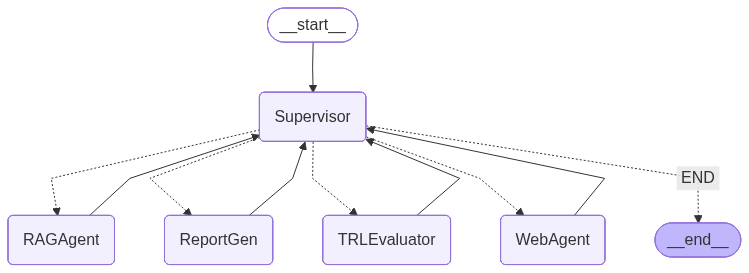

In [8]:
# 그래프 시각화
try:
    from IPython.display import display, Image
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print(graph.get_graph().draw_ascii())

## 4. 워크플로우 실행

### 4-1. 분석 주제 입력

In [9]:
# ✏️ 분석 주제를 자유롭게 변경하세요
QUERY = "Samsung과 Micron의 HBM4 및 PIM 기술 동향을 분석하고 TRL 기반으로 비교해주세요."

# 다른 예시:
# QUERY = "Samsung HBM4 Hybrid Bonding 특허 출원 현황과 TRL 추정"
# QUERY = "Micron CXL 표준화 전략과 SK Hynix 대비 위협 수준 분석"
# QUERY = "Samsung PIM 특허 공세와 SK Hynix 대응 전략"

print(f"📌 분석 주제: {QUERY}")

📌 분석 주제: Samsung과 Micron의 HBM4 및 PIM 기술 동향을 분석하고 TRL 기반으로 비교해주세요.


### 4-2. 그래프 실행 (스트리밍)

In [10]:
from utils.pretty_print import pretty_print_messages, print_workflow_summary

initial_state = get_initial_state(QUERY)
config        = {"configurable": {"thread_id": str(uuid.uuid4())}}
final_state   = initial_state.copy()
all_messages  = list(initial_state["messages"])  # 메시지 별도 누적

print(f"{'='*70}")
print(f"🚀 워크플로우 시작")
print(f"{'='*70}\n")

for chunk in graph.stream(initial_state, config=config, stream_mode="updates"):
    pretty_print_messages(chunk, last_message=True)
    for node_name, node_update in chunk.items():
        if isinstance(node_update, dict):
            # messages는 별도 누적, 나머지는 덮어쓰기
            if "messages" in node_update:
                all_messages.extend(node_update["messages"])
            final_state.update({k: v for k, v in node_update.items() if k != "messages"})

final_state["messages"] = all_messages  # 누적된 전체 메시지 반영
print_workflow_summary(final_state)


🚀 워크플로우 시작

📌 [Supervisor] 노드 업데이트:

================================== Ai Message ==================================

[Supervisor → WebAgent] 쿼리가 경쟁사 최신 동향 중심이므로 WebAgent를 우선적으로 활용하여 관련 정보를 수집해야 합니다.
지시: Samsung과 Micron의 HBM4 및 PIM 기술 관련 최신 특허, 논문, IR, 채용공고를 수집하세요. TRL 간접지표를 확보할 수 있도록 trl_clue 필드가 포함된 결과를 최소 3건 이상 수집해야 합니다.



Semantic Scholar rate limit — 5초 대기 후 재시도
Semantic Scholar rate limit — 10초 대기 후 재시도
Semantic Scholar rate limit — 15초 대기 후 재시도
Semantic Scholar rate limit — 5초 대기 후 재시도
Semantic Scholar rate limit — 10초 대기 후 재시도
Semantic Scholar rate limit — 15초 대기 후 재시도
Semantic Scholar rate limit — 5초 대기 후 재시도
Semantic Scholar rate limit — 10초 대기 후 재시도
Semantic Scholar 검색 실패 (Samsung CXL compute express link): 500 Server Error: Internal Server Error for url: https://api.semanticscholar.org/graph/v1/paper/search?query=Samsung+CXL+compute+express+link&limit=8&fields=title%2Cauthors%2Cyear%2Cvenue%2Cabstract%2CexternalIds%2CopenAccessPdf&publicationDateOrYear=2023-2025
Semantic Scholar rate limit — 5초 대기 후 재시도
Semantic Scholar rate limit — 10초 대기 후 재시도
Semantic Scholar rate limit — 15초 대기 후 재시도
Semantic Scholar rate limit — 5초 대기 후 재시도
Semantic Scholar rate limit — 10초 대기 후 재시도
Semantic Scholar rate limit — 15초 대기 후 재시도
KIPRIS XML 파싱 실패: mismatched tag: line 20, column 4
KIPRIS XML 파싱 실패: mismatched ta

📌 [WebAgent] 노드 업데이트:

================================== Ai Message ==================================

[WebAgent 완료] 총 10건 수집 (뉴스/논문: 10건, 특허: 0건, 채용공고: 0건)
- [N/A] HBM IP Filing Trends: Need, Major Players, and Patent Filings | TRL 3~6 추정 ★간접지표 기반
- [N/A] HBM-PIM: Cutting-edge memory technology to accelerate next ... | [TRL 추정 근거 없음]
- [N/A] Samsung Ships Industry-First Commercial HBM4 With Ultimate ... | TRL 7~9
- [N/A] Micron Technology: Memory's AI-Era Transformation and the HBM4 ... | [TRL 추정 근거 없음]
- [N/A] Micron's HBM4 and HBM4E Process Progress - Semicon | TRL 4~6 추정 ★간접지표 기반

📌 [Supervisor] 노드 업데이트:

================================== Ai Message ==================================

[Supervisor → RAGAgent] WebAgent를 통해 경쟁사 최신 동향 관련 정보는 충분히 수집되었으나, 기술 개념 및 메커니즘에 대한 내부 정보가 아직 수집되지 않았습니다. RAGAgent를 통해 기술 개념 중심의 정보를 확보할 필요가 있습니다.
지시: Samsung과 Micron의 HBM4 및 PIM 기술의 개념과 메커니즘에 대한 내부 벡터스토어 검색을 수행하세요. 관련 청크를 최소 3개 이상 확보해야 합니다.

📌 [RAGAgent] 노드 업데이트:

==================================

## 5. 결과 확인

In [11]:
# RAG 수집 결과 확인
rag_results = final_state.get("rag_results") or []
print(f"📚 RAG 검색 결과 ({len(rag_results)}건):")
for i, r in enumerate(rag_results[:5], 1):
    score = r.get('score', 0)
    bar = '█' * int(score * 10) + '░' * (10 - int(score * 10))
    print(f"  [{i}] {r.get('source','?')}")
    print(f"      점수: {bar} {score:.2f}")
    print(f"      요약: {r.get('summary','')[:100]}...")
    print()


📚 RAG 검색 결과 (5건):
  [1] pim_competitive.txt
      점수: ██████████ 1.00
      요약: 삼성은 2021년 HBM2E 기반 PIM 제품인 Aquabolt-XL을 세계 최초로 출시하며 DRAM 셀 배열과 프로세싱 유닛을 통합한 상용 HBM-PIM 제품을 선보였다. 이 제...

  [2] samsung_hbm4_analysis.txt
      점수: ████████░░ 0.85
      요약: Samsung은 PIM(Processing-In-Memory) 관련 특허를 국내외에서 다수 출원하며, SK Hynix보다 3~4배 많은 특허를 보유하고 있다. HBM-PIM 제품은...

  [3] pim_competitive.txt
      점수: ███████░░░ 0.70
      요약: Micron의 PIM 기술은 TRL 3~4로 추정되며, 관련 특허와 논문 수가 적어 불확실성이 높다. PIM 기술의 표준화 경쟁이 치열해지고 있으며, Samsung의 특허 포트폴리...

  [4] micron_hbm4_analysis.txt
      점수: █████░░░░░ 0.55
      요약: Micron Technology는 HBM3E 개발을 생략하고 HBM4에 R&D 역량을 집중하는 '기술 도약(Leapfrog)' 전략을 채택하여 2025년부터 주요 고객에게 HBM4...

  [5] micron_hbm4_analysis.txt
      점수: ████░░░░░░ 0.40
      요약: Micron의 CXL 기술은 현재 TRL 5~6으로 추정되며, 상용 제품 출시는 TRL 7~8 이후로 전망된다. 2024~2025년 채용공고에서 'HBM4 Architecture'...



In [12]:
# Web 수집 결과 확인
web_results = final_state.get("web_results") or []
print(f"🌐 Web 수집 결과 ({len(web_results)}건):")
for i, r in enumerate(web_results[:3], 1):
    print(f"  [{i}] {r.get('title','?')} ({r.get('date','N/A')})")
    print(f"      TRL 단서: {r.get('trl_clue','없음')}")
    print(f"      URL: {r.get('url','N/A')}")

🌐 Web 수집 결과 (10건):
  [1] HBM IP Filing Trends: Need, Major Players, and Patent Filings (N/A)
      TRL 단서: TRL 3~6 추정 ★간접지표 기반
      URL: https://sagaciousresearch.com/blog/hbm-ip-filing-trends-need-major-players-and-patent-filings
  [2] HBM-PIM: Cutting-edge memory technology to accelerate next ... (N/A)
      TRL 단서: [TRL 추정 근거 없음]
      URL: https://semiconductor.samsung.com/news-events/tech-blog/hbm-pim-cutting-edge-memory-technology-to-accelerate-next-generation-ai/
  [3] Samsung Ships Industry-First Commercial HBM4 With Ultimate ... (N/A)
      TRL 단서: TRL 7~9
      URL: https://news.samsung.com/global/samsung-ships-industry-first-commercial-hbm4-with-ultimate-performance-for-ai-computing


In [13]:
# 보고서 원문 확인 (Markdown 렌더링)
report = final_state.get("report", "")

if report:
    try:
        from IPython.display import display, Markdown
        display(Markdown(report))
    except Exception:
        print(report)
else:
    print("⚠️  생성된 보고서가 없습니다.")

# SK Hynix HBM 경쟁사 기술 동향 분석 보고서
**분석 주제**: Samsung과 Micron의 HBM4 및 PIM 기술 동향 분석
**생성 일시**: 2023년 10월 25일

## SUMMARY
본 보고서는 SK Hynix의 경쟁사인 Samsung과 Micron의 HBM4 및 PIM 기술 동향을 분석하고, TRL(Technology Readiness Level) 기반으로 비교하여 SK Hynix의 전략적 방향성을 제시합니다. Samsung은 HBM4와 PIM 기술에서 높은 TRL을 보이며 시장 주도권을 강화하고 있으며, Micron은 HBM4에 집중하는 '기술 도약' 전략을 통해 경쟁력을 확보하고자 합니다. SK Hynix는 이러한 경쟁사 동향을 바탕으로 R&D 우선순위를 재조정하고, 지속적인 모니터링을 통해 시장에서의 선도적 위치를 유지해야 합니다.

## 1. 분석 배경
### 1.1 왜 지금 이 기술을 분석해야 하는가
HBM4와 PIM 기술은 차세대 메모리 시장에서의 경쟁력을 좌우하는 핵심 요소로, AI 및 고성능 컴퓨팅(HPC) 수요 증가에 따라 중요성이 더욱 부각되고 있습니다. 경쟁사인 Samsung과 Micron의 기술 발전 상황을 파악함으로써 SK Hynix의 전략적 대응 방향을 설정할 필요가 있습니다.

### 1.2 분석 범위 및 방법론
본 보고서는 Samsung과 Micron의 HBM4 및 PIM 기술 동향을 중심으로, TRL을 기반으로 한 기술 성숙도를 비교 분석합니다. RAG 검색 결과와 최신 웹 수집 데이터를 활용하여 경쟁사의 기술적 위치와 시장 전략을 평가합니다.

## 2. 분석 대상 기술 현황
### 2.1 PIM 기술 현황
Samsung은 HBM2E 기반 PIM 제품을 세계 최초로 출시하며, PIM 기술에서 선도적 위치를 차지하고 있습니다. Micron은 PIM 기술에서 상대적으로 낮은 TRL을 보이며, HBM4 개발에 집중하고 있습니다.

### 2.2 CXL 기술 현황
Micron의 CXL 기술은 TRL 5~6으로 추정되며, 상용화까지 시간이 필요할 것으로 보입니다. SK Hynix와 Samsung의 관련 정보는 부재하여 경쟁력 평가가 어렵습니다.

### 2.3 HBM4 / Hybrid Bonding 현황
Samsung과 Micron은 HBM4의 상용 출하를 시작하여 높은 TRL을 보이고 있으며, 이는 시장에서의 경쟁력을 강화할 수 있는 요소로 작용할 수 있습니다.

## 3. 경쟁사 동향 분석
### 3.1 Samsung 동향
Samsung은 HBM4와 PIM 기술에서 높은 TRL을 보이며, 시장 주도권을 강화하고 있습니다. 특히, PIM 관련 특허를 다수 보유하여 HBM4 시대의 PIM 통합 메모리 표준 주도권 확보를 목표로 하고 있습니다.

### 3.2 Micron 동향
Micron은 HBM3E 개발을 생략하고 HBM4에 집중하는 '기술 도약' 전략을 채택하여, 2025년부터 주요 고객에게 HBM4를 공급할 계획입니다. PIM 기술에서는 상대적으로 낮은 TRL을 보이며, HBM4 출하 이후 가속화될 것으로 예상됩니다.

### 3.3 TRL 기반 비교 매트릭스
| 기술 영역 | SK Hynix | Samsung | Micron | 위협 수준 |
|-----------|----------|---------|--------|-----------|
| HBM3E (현재) | TRL 9 (양산 중) | TRL 7~8 * | TRL 7 * | 낮음 |
| HBM4 / Hybrid Bonding | TRL 6~7 * | TRL 7~9 | TRL 7~9 | 보통 |
| PIM | TRL 5~6 (AiMX) | TRL 7~9 | TRL 3~4 * | 높음 |
| CXL | TRL 7~8 (출시) | TRL 공개 정보 부재 | TRL 5~6 * | 보통 |

* TRL 4~6 구간: 간접지표 기반 추정. 불확실성 높음.

## 4. 전략적 시사점
### 4.1 R&D 우선순위 권고
SK Hynix는 PIM 기술의 상용화 가속과 고객 생태계 확대를 통해 시장에서의 선점 지위를 강화해야 합니다. 또한, HBM4 및 Hybrid Bonding 기술 개발에 집중하여 경쟁력을 확보해야 합니다.

### 4.2 모니터링 지속 대상
Samsung의 PIM 특허 전략과 Micron의 HBM4 개발 동향을 지속적으로 모니터링하여, 시장 변화에 신속히 대응할 수 있는 체계를 구축해야 합니다.

### 4.3 분석 한계 및 주의사항
본 보고서는 공개된 정보에 기반하여 작성되었으며, 일부 TRL은 간접지표 기반으로 추정되었습니다. 따라서, 실제 기술 성숙도와 차이가 있을 수 있음을 유의해야 합니다.

## REFERENCE
1. pim_competitive.txt
2. samsung_hbm4_analysis.txt
3. micron_hbm4_analysis.txt
4. HBM IP Filing Trends: Need, Major Players, and Patent Filings
5. Samsung Ships Industry-First Commercial HBM4 With Ultimate Performance for AI Computing

## 6. 보고서 PDF 저장
**필수 산출물**: `outputs/` 디렉토리에 PDF 파일로 저장

In [14]:
from utils.pdf_exporter import export_to_pdf
from datetime import datetime

if report:
    ts = datetime.now().strftime("%Y%m%d_%H%M")
    saved_path = export_to_pdf(
        report,
        filename=f"HBM_경쟁사분석보고서_{ts}",
    )
    print(f"\n📄 보고서 저장 완료: {saved_path}")
else:
    print("⚠️  저장할 보고서가 없습니다. 워크플로우를 다시 실행하세요.")

  ✅ PDF 저장 완료 (weasyprint): /Users/skala059/workspace/ai-service/hbm-competitive-intel/outputs/HBM_경쟁사분석보고서_20260415_1437.pdf

📄 보고서 저장 완료: /Users/skala059/workspace/ai-service/hbm-competitive-intel/outputs/HBM_경쟁사분석보고서_20260415_1437.pdf


## 7. RAG 평가 — Hit Rate@K / MRR
설계서 Success Criteria: Hit Rate@5 ≥ 0.80 / MRR ≥ 0.70

In [15]:
from rag.retriever import retrieve_with_scores

def evaluate_retriever(retriever, eval_set: list, k: int = 5) -> dict:
    """Hit Rate@K 및 MRR 계산"""
    hits, reciprocal_ranks = 0, []
    for item in eval_set:
        results = retrieve_with_scores(retriever, item["query"], k=k)
        sources = [r["source"] for r in results]
        hit = any(item["expected_source"] in s for s in sources)
        if hit:
            hits += 1
            for rank, s in enumerate(sources, 1):
                if item["expected_source"] in s:
                    reciprocal_ranks.append(1.0 / rank)
                    break
        else:
            reciprocal_ranks.append(0.0)
    n = len(eval_set)
    return {
        f"Hit Rate@{k}": round(hits / n, 3) if n > 0 else 0.0,
        "MRR":          round(sum(reciprocal_ranks) / n, 3) if n > 0 else 0.0,
    }

# 실제 data/ 파일명 기준 평가셋
EVAL_SET = [
    {"query": "Samsung HBM4 양산 현황과 Hybrid Bonding",  "expected_source": "samsung_hbm4_analysis"},
    {"query": "Micron HBM4 Leapfrog 전략",              "expected_source": "micron_hbm4_analysis"},
    {"query": "Samsung Micron PIM 기술 TRL 비교",        "expected_source": "pim_competitive"},
    {"query": "CXL 표준화 경쟁 Micron",                 "expected_source": "cxl_landscape"},
    {"query": "HBM4 Hybrid Bonding Cu-Cu 접합",         "expected_source": "hbm4_hybrid_bonding"},
    {"query": "TRL 간접지표 추정 채용공고",               "expected_source": "trl_framework"},
    {"query": "SK Hynix AiMX PIM 경쟁사",               "expected_source": "pim_competitive"},
    {"query": "HBM 시장 성장 전망 AI 반도체",            "expected_source": "samilpwc_semicon"},
]

metrics = evaluate_retriever(retriever, EVAL_SET, k=5)
print("📊 RAG 평가 결과 (실제 파일 기준):")
for metric, value in metrics.items():
    target = 0.80 if "Hit" in metric else 0.70
    status = "✅ 통과" if value >= target else "⚠️  기준 미달"
    bar = '█' * int(value * 20) + '░' * (20 - int(value * 20))
    print(f"  {metric}: {bar} {value:.3f} (기준 {target}) {status}")


📊 RAG 평가 결과 (실제 파일 기준):
  Hit Rate@5: ████████████████████ 1.000 (기준 0.8) ✅ 통과
  MRR: ████████████████░░░░ 0.823 (기준 0.7) ✅ 통과


## 8. 전체 메시지 히스토리 확인 (디버깅)

In [16]:
messages = final_state.get("messages", [])
print(f"📬 전체 메시지 히스토리 ({len(messages)}개):\n")

node_icons = {
    'supervisor': '🎯', 'rag_agent': '📚', 'web_agent': '🌐',
    'trl_evaluator': '🔬', 'report_generator': '📝', 'HumanMessage': '👤'
}

for i, msg in enumerate(messages, 1):
    name    = getattr(msg, 'name', None) or type(msg).__name__.replace('Message','')
    icon    = node_icons.get(name, '💬')
    content = str(msg.content)[:120].replace('\n', ' ')
    msg_type = type(msg).__name__.replace('Message', '')
    print(f"  {icon} [{i:02d}] {name} ({msg_type})")
    print(f"       {content}...")
    print()


📬 전체 메시지 히스토리 (10개):

  💬 [01] Human (Human)
       Samsung과 Micron의 HBM4 및 PIM 기술 동향을 분석하고 TRL 기반으로 비교해주세요....

  💬 [02] AI (AI)
       [Supervisor → WebAgent] 쿼리가 경쟁사 최신 동향 중심이므로 WebAgent를 우선적으로 활용하여 관련 정보를 수집해야 합니다. 지시: Samsung과 Micron의 HBM4 및 PIM 기술 관련 ...

  💬 [03] AI (AI)
       [WebAgent 완료] 총 10건 수집 (뉴스/논문: 10건, 특허: 0건, 채용공고: 0건) - [N/A] HBM IP Filing Trends: Need, Major Players, and Patent Fili...

  💬 [04] AI (AI)
       [Supervisor → RAGAgent] WebAgent를 통해 경쟁사 최신 동향 관련 정보는 충분히 수집되었으나, 기술 개념 및 메커니즘에 대한 내부 정보가 아직 수집되지 않았습니다. RAGAgent를 통해 기술...

  💬 [05] AI (AI)
       [RAGAgent 완료] 5건의 관련 문서 청크를 검색했습니다. - pim_competitive.txt: 삼성은 2021년 HBM2E 기반 PIM 제품인 Aquabolt-XL을 세계 최초로 출시하며 DRAM 셀 배열...

  💬 [06] AI (AI)
       [Supervisor → TRLEvaluator] RAG+Web 수집 완료 — TRL 평가 단계로 이동. 지시: ...

  🔬 [07] trl_evaluator (AI)
       ```json {   "evaluated_at": "2023-10-25",   "technologies": {     "HBM4": {       "SK Hynix": {         "trl": "공개 정보 부재...

  💬 [08] AI (AI)
       [Supervisor → R

## [교수 피드백 반영] A. 임베딩 후보군 비교
"bge 계열 외 Jina Embedding, Voyage AI voyage-3-large도 검토 가능합니다."

In [17]:
from rag.embeddings import print_embedding_catalog, EMBEDDING_CATALOG

# 후보군 비교표 출력
print_embedding_catalog()

# ✏️ 모델 변경 방법:
# EMBED_MODEL = "jina-v3"         # Jina v3 (한영 혼용, 8192t)
# EMBED_MODEL = "voyage-3-large"   # Voyage AI (영문 기술문서 특화, API 필요)
# EMBED_MODEL = "multilingual-e5-large"  # E5 (512t, 안정적)
EMBED_MODEL = "bge-m3"   # 현재 선택 (변경 후 아래 셀 재실행)
print(f"현재 선택: {EMBED_MODEL}")
print(f"특징: {EMBEDDING_CATALOG[EMBED_MODEL]['note']}")


📊 임베딩 모델 후보군 비교 (HBM 도메인 기준)
키                         타입       토큰      언어              비용           비고
------------------------------------------------------------------------------------------
bge-m3                    local    8192    한·영 혼용          무료           멀티벡터(dense+sparse+colbert). HBM 전문용어 처리 
multilingual-e5-large     local    512     한·영 혼용          무료           컨텍스트 길이 제한(512t). 짧은 청크 환경에서 안정적.
jina-v3                   local    8192    한·영 혼용          무료 (로컬)      태스크별 LoRA 어댑터. retrieval 태스크 특화 설정 가능. 신
voyage-3-large            api      16000   영문 중심 (한국어 지원)  유료 (VOYAGE_API_KEY 필요) 영문 기술 문서(특허·논문) 검색 성능 최상위권. API 비용 발생.
ko-sroberta               local    512     한국어 특화          무료           한국어 문서 전용. 영문 특허·논문 혼용 환경에서는 성능 저하 우려.

현재 선택: bge-m3
특징: 멀티벡터(dense+sparse+colbert). HBM 전문용어 처리 우수. 1순위 기본값.


## [교수 피드백 반영] B. RAG 검색 전략 비교 평가
"데이터에 부합하는 retrieve가 무엇인지 RAG 평가를 통해 확인해 주세요."

In [18]:
# 교수 피드백: RAG 전략 비교 평가 (실제 data/ 파일 기준)
from rag.retriever import evaluate_retrievers, print_eval_table, HBM_EVAL_SAMPLES

# 팀원 개선: 실제 파일 기준 eval set (semiconductor_terms.json + samilpwc PDF)
EVAL_SET = [
    {"query": s.query, "expected_source": s.relevant_sources[0]}
    for s in HBM_EVAL_SAMPLES
]

print(f'📋 평가셋 ({len(EVAL_SET)}개):'
      '\n' + '\n'.join(f"  - {e['query'][:50]}" for e in EVAL_SET[:5]) + '\n  ...')
print('\n🔬 4가지 검색 전략 평가 시작...\n')

eval_results = evaluate_retrievers(
    vectorstore=vectorstore,
    all_chunks=all_docs,
    eval_set=EVAL_SET,
    k=5,
)
print_eval_table(eval_results, k=5)


📋 평가셋 (10개):
  - Samsung HBM4 양산 현황과 Hybrid Bonding 전략
  - Micron HBM4 Leapfrog 전략과 CHIPS Act 지원
  - Samsung과 Micron의 PIM 기술 TRL 비교
  - CXL 표준화 경쟁과 Micron의 전략
  - HBM4 Hybrid Bonding Cu-Cu 접합 기술
  ...

🔬 4가지 검색 전략 평가 시작...

  📏 평가: Naive (Dense) ... Hit@5=1.000  MRR=0.900
  📏 평가: Hybrid (BM25+RRF) ... Hit@5=1.000  MRR=0.850
  📏 평가: HyDE ... Hit@5=0.900  MRR=0.850
  📏 평가: MultiQuery ... Hit@5=1.000  MRR=0.900

📊 RAG 검색 전략 비교 (k=5)
  전략                        Hit Rate@5     MRR
  --------------------------------------------------
  Naive (Dense)             ✅1.000         ✅0.900  ★
  Hybrid (BM25+RRF)         ✅1.000         ✅0.850  
  HyDE                      ✅0.900         ✅0.850  
  MultiQuery                ✅1.000         ✅0.900  ★

  기준: Hit Rate@5≥0.80 / MRR≥0.70



In [19]:
from rag.retriever import (
    NaiveRetriever, HBMRetriever, HyDERetriever, MultiQueryRetriever
)

class _HybridForMap:
    def __init__(self, vs, docs, k=5):
        from langchain_community.retrievers import BM25Retriever
        self._vs = vs
        self.k = k
        self._bm25 = BM25Retriever.from_documents(docs, k=k*2)
    def invoke(self, q):
        from rag.retriever import RRF_K
        scores, dmap = {}, {}
        def key(d): return d.page_content[:100]
        for i, d in enumerate(self._bm25.invoke(q), 1):
            k_ = key(d); scores[k_] = scores.get(k_, 0) + 1/(RRF_K+i); dmap[k_] = d
        for i, d in enumerate(self._vs.similarity_search(q, k=self.k*2), 1):
            k_ = key(d); scores[k_] = scores.get(k_, 0) + 1/(RRF_K+i); dmap[k_] = d
        return [dmap[k] for k in sorted(scores, key=lambda x: scores[x], reverse=True)[:self.k]]

STRATEGY_MAP = {
    "Naive (Dense)":     lambda: NaiveRetriever(vectorstore, k=5),
    "Hybrid (BM25+RRF)": lambda: _HybridForMap(vectorstore, all_docs, k=5),
    "HyDE":              lambda: HyDERetriever(vectorstore, k=5),
    "MultiQuery":        lambda: MultiQueryRetriever(vectorstore, k=5),
}

# ✏️ 평가 결과에서 최고 전략으로 변경
BEST_STRATEGY = "HyDE"

retriever = STRATEGY_MAP[BEST_STRATEGY]()
from agents.rag_agent import init_rag_retriever
init_rag_retriever(retriever)

# ── 선택된 전략으로 테스트 검색 ──────────────────────────────
TEST_QUERY = "Samsung HBM4 Hybrid Bonding 기술 동향"
test_docs = retriever.invoke(TEST_QUERY)

print(f"\n{'='*60}")
print(f"✅ 검색 전략 교체 완료")
print(f"{'='*60}")
print(f"  선택 전략  : {BEST_STRATEGY}")
print(f"  리트리버   : {type(retriever).__name__}")
print(f"  테스트 쿼리: {TEST_QUERY}")
print(f"  검색 결과  : {len(test_docs)}건")
print(f"{'─'*60}")
for i, doc in enumerate(test_docs[:3], 1):
    source = doc.metadata.get('source', 'unknown')
    dtype  = doc.metadata.get('doc_type', '')
    page   = doc.metadata.get('page', '')
    loc    = f"p.{page}" if page else dtype
    print(f"  [{i}] {source} ({loc})")
    print(f"      {doc.page_content[:80].strip()}...")
print(f"{'='*60}")
print(f"\n💡 전략을 바꾸려면 BEST_STRATEGY 값을 변경 후 재실행:")
for name in STRATEGY_MAP:
    marker = "◀ 현재" if name == BEST_STRATEGY else ""
    print(f"   - \"{name}\" {marker}")


✅ 검색 전략 교체 완료
  선택 전략  : HyDE
  리트리버   : _HyDERetriever
  테스트 쿼리: Samsung HBM4 Hybrid Bonding 기술 동향
  검색 결과  : 5건
────────────────────────────────────────────────────────────
  [1] hbm4_hybrid_bonding.txt (text)
      # HBM4 및 Hybrid Bonding 기술 심층 분석 ## 1. HBM4 기술 개요 HBM4(High Bandwidth Memory 4)는...
  [2] samsung_hbm4_analysis.txt (text)
      # Samsung HBM4 기술 동향 분석 ## 1. HBM4 개발 현황 및 양산 전략 Samsung Electronics는 2025년 HBM4...
  [3] micron_hbm4_analysis.txt (text)
      # Micron HBM4 기술 동향 및 전략 분석 ## 1. HBM4 직행 전략 (Leapfrog) Micron Technology는 HBM3E...

💡 전략을 바꾸려면 BEST_STRATEGY 값을 변경 후 재실행:
   - "Naive (Dense)" 
   - "Hybrid (BM25+RRF)" 
   - "HyDE" ◀ 현재
   - "MultiQuery" 


## [교수 피드백 반영] C. TRL Evaluator 노드 확인
"TRL 평가가 node 또는 에이전트 형태까지 고려되었는지 검토해 주시기 바랍니다."

📋 TRL Evaluator 노드 — 워크플로우 내 위치:

START → Supervisor
  → RAGAgent      (기술 개념 검색)
  → Supervisor
  → WebAgent      (최신 공개정보 수집)
  → Supervisor
  → TRLEvaluator  ★ 신규 노드 — RAG+Web 근거로 TRL 구조화 평가
  → Supervisor
  → ReportGen     (TRL 평가 결과 포함 보고서 작성)
  → Supervisor
  → END



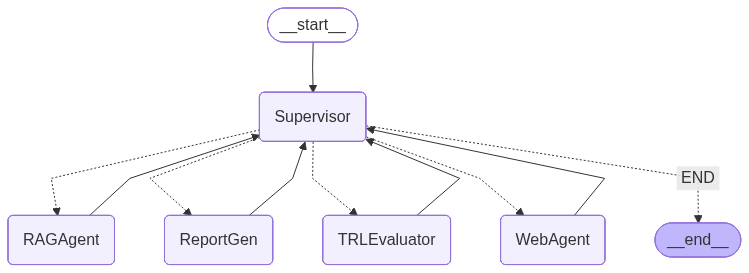

In [20]:
import inspect
from agents.trl_evaluator import trl_evaluator_node

print("📋 TRL Evaluator 노드 — 워크플로우 내 위치:")
print("""
START → Supervisor
  → RAGAgent      (기술 개념 검색)
  → Supervisor
  → WebAgent      (최신 공개정보 수집)
  → Supervisor
  → TRLEvaluator  ★ 신규 노드 — RAG+Web 근거로 TRL 구조화 평가
  → Supervisor
  → ReportGen     (TRL 평가 결과 포함 보고서 작성)
  → Supervisor
  → END
""")

# 업데이트된 그래프 시각화
from graph.workflow import build_graph
graph = build_graph(use_checkpointer=True)
try:
    from IPython.display import display, Image
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print(graph.get_graph().draw_ascii())